In [41]:
import os
from datetime import datetime
from urllib.parse import quote_plus

import feedparser
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Add,
    Conv1D,
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    Input,
    Lambda,
    LayerNormalization,
    LSTM,
    Multiply,
)
from tensorflow.keras.models import Model, Sequential
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging
from xgboost import XGBRegressor


In [42]:
# Global configuration
hf_logging.set_verbosity_error()
os.environ["HF_TOKEN"] = ""

ticker = "GC=F"
start = datetime(2020, 1, 1)
end = datetime(2025, 10, 1)
split_size = 0.8



In [43]:
# Data preparation functions
def add_features(df):
    data = df.copy()
    data["MA7"] = data["Close"].rolling(7).mean()
    data["MA30"] = data["Close"].rolling(30).mean()
    data["LogRet"] = np.log(data["Close"]) - np.log(data["Close"].shift(1))
    return data.dropna()


def prepare_data(ticker, start, end, split_size):
    data = yf.download(ticker, start=start, end=end)
    data_feat = add_features(data)
    split = int(len(data) * split_size)

    train_feat = data_feat[:split]
    test_feat = data_feat[split:]

    feature_cols = ["Close", "MA7", "MA30", "LogRet"]
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_feat[feature_cols].values)

    combined = pd.concat((train_feat[feature_cols], test_feat[feature_cols]), axis=0)
    test_scaled = scaler.transform(combined.values)

    prediction_days = 30
    x_train, y_train, x_test = [], [], []

    for i in range(prediction_days, len(train_scaled)):
        x_train.append(train_scaled[i - prediction_days:i])
        y_train.append(train_scaled[i, 0])

    for i in range(len(train_feat), len(combined)):
        if i - prediction_days >= 0:
            x_test.append(test_scaled[i - prediction_days:i])

    return (
        np.array(x_test), np.array(x_train), np.array(y_train),
        scaler, prediction_days, feature_cols, train_feat, test_feat, data
    )


x_test, x_train, y_train, scaler, prediction_days, feature_cols, train_data, test_data, raw_data = prepare_data(
    ticker, start, end, split_size
)
date_window = raw_data.index



C:\Users\dev26\AppData\Local\Temp\ipykernel_16272\2110630071.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [44]:
# LSTM model building and training
def lstm_build_model(input_shape):
    model = Sequential([
        LSTM(256, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(256, return_sequences=True),
        Dropout(0.2),
        LSTM(256),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def train_model(model, x_train, y_train):
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = model.fit(
        x_train, y_train,
        epochs=25,
        batch_size=16,
        validation_split=0.1,
        callbacks=[es],
        verbose=1
    )
    return model, history


def predict(model, x_test, scaler):
    preds = model.predict(x_test)
    pad_cols = len(feature_cols) - 1
    padded = np.concatenate([preds, np.zeros((preds.shape[0], pad_cols))], axis=1)
    return scaler.inverse_transform(padded)[:, 0]


lstm_model = lstm_build_model((x_train.shape[1], x_train.shape[2]))
lstm_model, history = train_model(lstm_model, x_train, y_train)
predicted_prices = predict(lstm_model, x_test, scaler)



C:\Users\dev26\Documents\FinanceML\.venv1\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 0.0055 - val_loss: 0.0017
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.0027 - val_loss: 0.0136
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 8.1572e-04 - val_loss: 0.0041
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 8.1649e-04 - val_loss: 9.3622e-04
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 7.5177e-04 - val_loss: 0.0038
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 9.6743e-04 - val_loss: 0.0015
Epoch 9/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 7.2570e-04 - val_loss: 0.0015
Epoch 10/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 6.6726e-04 - val_loss: 5.7861e-04
Epoch 11/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 8.2201e-04 - val_loss: 0.0025
Epoch 12/25
64/64 ━━━━━━━━━

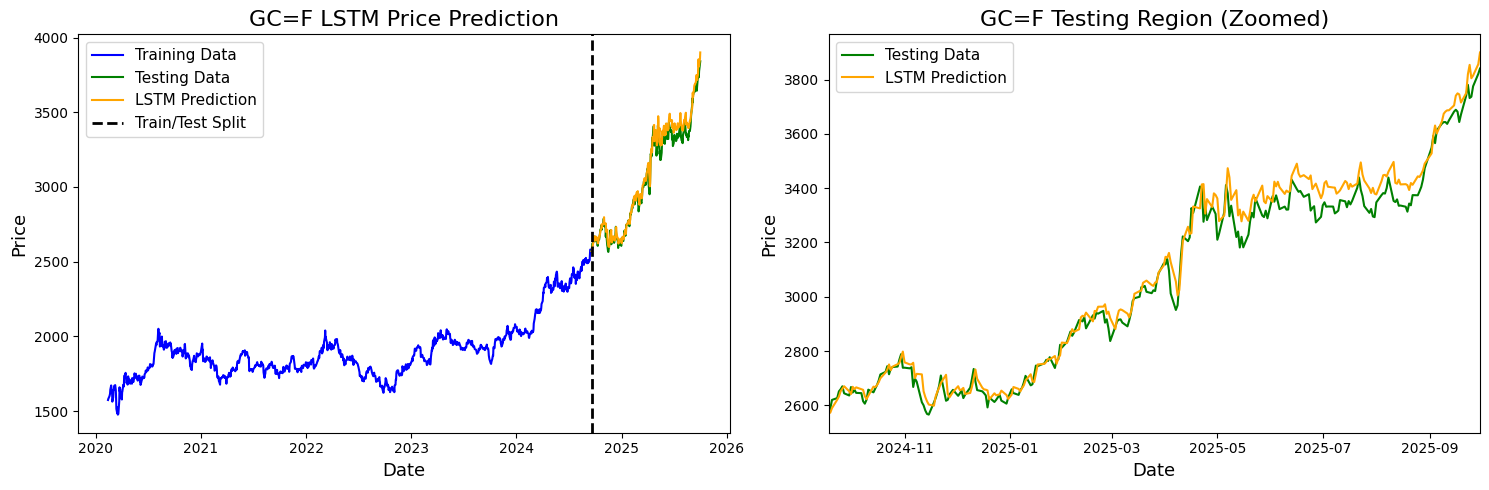

In [45]:
# LSTM visualization
def plot_lstm_results(train_data, test_data, predicted_prices, company_name):
    train_prices = train_data["Close"].values
    test_prices = test_data["Close"].values

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Full view
    axes[0].plot(train_data.index, train_prices, label="Training Data", color="blue")
    axes[0].plot(test_data.index, test_prices, label="Testing Data", color="green")
    axes[0].plot(test_data.index, predicted_prices, label="LSTM Prediction", color="orange")
    axes[0].axvline(x=test_data.index[0], color="black", linestyle="--", linewidth=2, label="Train/Test Split")
    axes[0].set_title(f"{company_name} LSTM Price Prediction", fontsize=16)
    axes[0].set_xlabel("Date", fontsize=13)
    axes[0].set_ylabel("Price", fontsize=13)
    axes[0].legend(fontsize=11)

    # Zoomed test view
    axes[1].plot(test_data.index, test_prices, label="Testing Data", color="green")
    axes[1].plot(test_data.index, predicted_prices, label="LSTM Prediction", color="orange")
    axes[1].set_xlim(test_data.index.min(), test_data.index.max())
    axes[1].set_title(f"{company_name} Testing Region (Zoomed)", fontsize=16)
    axes[1].set_xlabel("Date", fontsize=13)
    axes[1].set_ylabel("Price", fontsize=13)
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.show()


plot_lstm_results(train_data, test_data, predicted_prices, ticker)



In [46]:
# Model evaluation
def evaluate_model(actual_prices, predicted_prices):
    if len(actual_prices) != len(predicted_prices):
        actual_prices = actual_prices[-len(predicted_prices):]

    actual_prices = np.asarray(actual_prices).reshape(-1)
    predicted_prices = np.asarray(predicted_prices).reshape(-1)

    mae = mean_absolute_error(actual_prices, predicted_prices)
    rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
    r2 = r2_score(actual_prices, predicted_prices)

    actual_diff = np.diff(actual_prices)
    pred_diff = np.diff(predicted_prices)
    directional_accuracy = np.mean(np.sign(actual_diff) == np.sign(pred_diff))

    actual_returns = np.diff(np.log(actual_prices))
    predicted_returns = np.diff(np.log(predicted_prices))
    return_mse = mean_squared_error(actual_returns, predicted_returns)

    return {
        "RMSE": rmse, "MAE": mae,
        "R2": r2, "Directional Acc": directional_accuracy,
        "Return MSE": return_mse
    }


In [47]:
# News fetching and embedding
def get_stock_news(company_name, ticker, sources, start_date, end_date, max_articles=1):
    query = quote_plus(
        f'({company_name} OR {ticker}) ({sources}) '
        f'after:{start_date.strftime("%Y-%m-%d")} '
        f'before:{end_date.strftime("%Y-%m-%d")}'
    )
    rss_url = f'https://news.google.com/rss/search?q={query}&hl=en-GB&gl=GB&ceid=GB:en'
    feed = feedparser.parse(rss_url)

    news_items = [entry.title for entry in feed.entries[:max_articles]]
    return news_items[0] if len(news_items) == 1 else news_items


def fetch_news(date_window, interval):
    cache_file = f"news_cache_interval_{interval}.pkl"
    if os.path.exists(cache_file):
        return pd.read_pickle(cache_file)

    all_news = []
    for i in range(0, len(date_window) - 1, interval):
        news = get_stock_news(
            "Gold price OR Federal Reserve OR Bonds",
            "GC=F OR XAUUSD OR GOLD",
            "site:reuters.com OR site:wsj.com OR site:ft.com",
            start_date=date_window[i],
            end_date=date_window[i + 1]
        )
        all_news.append([date_window[i], news])

    all_news = pd.DataFrame(all_news, columns=["Date", "News"]).set_index("Date")
    all_news.to_pickle(cache_file)
    return all_news


tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
finbert_model = AutoModel.from_pretrained("ProsusAI/finbert")


def embed_headline(headline):
    inputs = tokenizer(headline, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = finbert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze(0).numpy()


interval = 1
news_df = fetch_news(date_window, interval=interval)



In [48]:
# Build news features
def build_news_dataframe(df, date_window):
    df["Price"] = 0.0
    df["Gradient"] = 0.0
    df["Next_Price"] = 0.0
    df["Embedded_Headline"] = [""] * len(df)

    for i in range(len(df)):
        current_date = df.index[i]
        pos = date_window.get_loc(current_date)

        current_price = raw_data.iloc[pos]["Close"][0]
        next_price = raw_data.iloc[pos + 1]["Close"][0]
        days_diff = (date_window[i + 1] - date_window[i]).days

        df.at[current_date, "Price"] = current_price
        df.at[current_date, "Next_Price"] = next_price
        df.at[current_date, "Gradient"] = (next_price - current_price) / days_diff
        df.at[current_date, "Embedded_Headline"] = embed_headline(df.at[current_date, "News"])


build_news_dataframe(news_df, date_window)



C:\Users\dev26\AppData\Local\Temp\ipykernel_16272\4054742002.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_price = raw_data.iloc[pos]["Close"][0]
C:\Users\dev26\AppData\Local\Temp\ipykernel_16272\4054742002.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_price = raw_data.iloc[pos + 1]["Close"][0]


In [49]:
# Prepare sentiment model data
def prep_train_test_data(news_df, split_size=0.8):
    n_last = int(len(news_df) * (1 - split_size))
    sampled_idx = news_df.iloc[-n_last:].index
    news_df.loc[sampled_idx, 'Gradient'] = None

    headlines = [r['Embedded_Headline'] for _, r in news_df.iterrows()]
    gradient = [r['Gradient'] for _, r in news_df.iterrows()]

    labeled_idx = [i for i, s in enumerate(gradient) if s is not None and not np.isnan(s)]
    unlabeled_idx = [i for i, s in enumerate(gradient) if s is None or np.isnan(s)]

    X_labeled = np.stack([headlines[i] for i in labeled_idx])
    y_labeled = np.array([gradient[i] for i in labeled_idx], dtype=float)

    return X_labeled, y_labeled, X_labeled.shape[1], labeled_idx, unlabeled_idx, headlines, gradient


X_labeled, y_labeled, input_dim, labeled_idx, unlabeled_idx, headlines, gradient = prep_train_test_data(
    news_df, split_size
)



In [50]:
# Mamba-inspired sentiment model
def mamba_block(x, d_model, dropout_rate=0.2):
    projected = Dense(d_model)(x)
    state = Conv1D(filters=d_model, kernel_size=3, padding="causal", activation="swish")(projected)
    gate = Dense(d_model, activation="sigmoid")(projected)
    gated_state = Multiply()([state, gate])
    x = Add()([projected, gated_state])
    x = LayerNormalization()(x)
    return Dropout(dropout_rate)(x)


def mamba_build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Lambda(lambda t: tf.expand_dims(t, axis=-1))(inputs)
    x = mamba_block(x, 64, dropout_rate=0.2)
    x = mamba_block(x, 64, dropout_rate=0.2)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation="swish")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


sentiment_model = mamba_build_model((input_dim,))
sentiment_model, _ = train_model(sentiment_model, X_labeled, y_labeled)


Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 280.3855 - mae: 11.4259 - val_loss: 452.7247 - val_mae: 15.6646
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 280.4023 - mae: 11.4344 - val_loss: 451.6145 - val_mae: 15.6248
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 280.1129 - mae: 11.4145 - val_loss: 451.2447 - val_mae: 15.6115
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 280.3557 - mae: 11.4218 - val_loss: 453.8163 - val_mae: 15.7018
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 280.2870 - mae: 11.4387 - val_loss: 451.8452 - val_mae: 15.6347
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 280.2049 - mae: 11.4190 - val_loss: 451.1643 - val_mae: 15.6095
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 280.2942 - mae: 11.4192 - val_loss: 451.9828 - val_mae: 15.6397
Epoch 8/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 280.0190 - mae: 11.4223 - val_loss: 453.1266 - val_mae: 15.6793
Epoch 9/25
66/66

In [51]:
# Generate sentiment predictions
X_all = np.stack(headlines)
all_gradient_predictions = sentiment_model.predict(X_all).flatten()
news_df["Predicted_Gradient"] = all_gradient_predictions

news_df = news_df.groupby(news_df.index.normalize()).agg({
    "Gradient": "mean",
    "Predicted_Gradient": "mean",
    **{col: "first" for col in news_df.columns if col not in ["Gradient", "Predicted_Gradient"]}
})



46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [52]:
# XGBoost stacking preparation
def get_close_series(df):
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    return pd.Series(close.astype(float).values, index=df.index, name="Close")


def predict_to_price(model, X, scaler, feature_cols):
    preds = model.predict(X, verbose=0).reshape(-1, 1)
    padded = np.concatenate([preds, np.zeros((len(preds), len(feature_cols) - 1))], axis=1)
    return scaler.inverse_transform(padded)[:, 0]


def build_sentiment_price_series(news_df, trading_index):
    trading_days = pd.DatetimeIndex(trading_index).normalize().unique()
    sentiment_rows, gradient_rows = [], []

    for current_date, row in news_df.sort_index().iterrows():
        current_date = pd.Timestamp(current_date).normalize()
        if current_date not in trading_days:
            continue

        pos = trading_days.get_loc(current_date)
        if pos + 1 >= len(trading_days):
            continue

        next_trading_date = trading_days[pos + 1]
        gap_days = max((next_trading_date - current_date).days, 1)
        predicted_next_price = float(row["Price"]) + float(row["Predicted_Gradient"]) * gap_days

        sentiment_rows.append((next_trading_date, predicted_next_price))
        gradient_rows.append((next_trading_date, float(row["Predicted_Gradient"])))

    sentiment_series = (
        pd.DataFrame(sentiment_rows, columns=["Date", "sa_pred"])
        .drop_duplicates(subset="Date", keep="last")
        .set_index("Date")["sa_pred"]
        .sort_index()
    )

    gradient_series = (
        pd.DataFrame(gradient_rows, columns=["Date", "sa_gradient"])
        .drop_duplicates(subset="Date", keep="last")
        .set_index("Date")["sa_gradient"]
        .sort_index()
    )

    return sentiment_series, gradient_series


close_series = get_close_series(raw_data)
ts_train_pred = predict_to_price(lstm_model, x_train, scaler, feature_cols)
ts_train_series = pd.Series(ts_train_pred, index=train_data.index[prediction_days:], name="ts_pred")
ts_test_series = pd.Series(predicted_prices, index=test_data.index, name="ts_pred")
sa_price_series, sa_gradient_series = build_sentiment_price_series(news_df, raw_data.index)

# Build meta-features for XGBoost
common_train_dates = ts_train_series.index.intersection(sa_price_series.index)
meta_train_df = pd.DataFrame(index=common_train_dates)
meta_train_df["ts_pred"] = ts_train_series.reindex(common_train_dates)
meta_train_df["sa_pred"] = sa_price_series.reindex(common_train_dates)
meta_train_df["sa_gradient"] = sa_gradient_series.reindex(common_train_dates)
meta_train_df["pred_gap"] = meta_train_df["sa_pred"] - meta_train_df["ts_pred"]
meta_train_df["pred_gap_pct"] = meta_train_df["pred_gap"] / meta_train_df["ts_pred"]
meta_train_df["y"] = close_series.reindex(common_train_dates)
meta_train_df["target_residual"] = meta_train_df["y"] - meta_train_df["ts_pred"]
meta_train_df = meta_train_df.dropna()

common_test_dates = ts_test_series.index.intersection(sa_price_series.index)
meta_test_df = pd.DataFrame(index=common_test_dates)
meta_test_df["ts_pred"] = ts_test_series.reindex(common_test_dates)
meta_test_df["sa_pred"] = sa_price_series.reindex(common_test_dates)
meta_test_df["sa_gradient"] = sa_gradient_series.reindex(common_test_dates)
meta_test_df["pred_gap"] = meta_test_df["sa_pred"] - meta_test_df["ts_pred"]
meta_test_df["pred_gap_pct"] = meta_test_df["pred_gap"] / meta_test_df["ts_pred"]
meta_test_df["y"] = close_series.reindex(common_test_dates)
meta_test_df = meta_test_df.dropna()

stack_features = ["ts_pred", "sa_pred", "sa_gradient", "pred_gap", "pred_gap_pct"]

split_idx = max(int(len(meta_train_df) * 0.8), 1)
stack_train = meta_train_df.iloc[:split_idx].copy()
stack_valid = meta_train_df.iloc[split_idx:].copy()

# Train XGBoost stacker
xgb_stacker = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=2.0,
    random_state=42
)

if len(stack_valid) > 0:
    xgb_stacker.fit(
        stack_train[stack_features],
        stack_train["target_residual"],
        eval_set=[(stack_valid[stack_features], stack_valid["target_residual"])],
        verbose=False
    )
else:
    xgb_stacker.fit(
        meta_train_df[stack_features],
        meta_train_df["target_residual"],
        verbose=False
    )

predicted_residual = xgb_stacker.predict(meta_test_df[stack_features])
xgb_combined_series = pd.Series(
    meta_test_df["ts_pred"].values + predicted_residual,
    index=meta_test_df.index,
    name="xgb_combined_pred"
)

ts_test_aligned = meta_test_df["ts_pred"].copy()
sa_test_aligned = meta_test_df["sa_pred"].copy()
actual_test_aligned = meta_test_df["y"].copy()

print(f"Meta-train rows: {len(meta_train_df)}")
print(f"Meta-test rows: {len(meta_test_df)}")
print(f"Stack features: {stack_features}")
print(pd.Series(xgb_stacker.feature_importances_, index=stack_features).sort_values(ascending=False))



Meta-train rows: 1126
Meta-test rows: 261
Stack features: ['ts_pred', 'sa_pred', 'sa_gradient', 'pred_gap', 'pred_gap_pct']
pred_gap_pct    0.329331
pred_gap        0.242987
ts_pred         0.153726
sa_gradient     0.144748
sa_pred         0.129208
dtype: float32


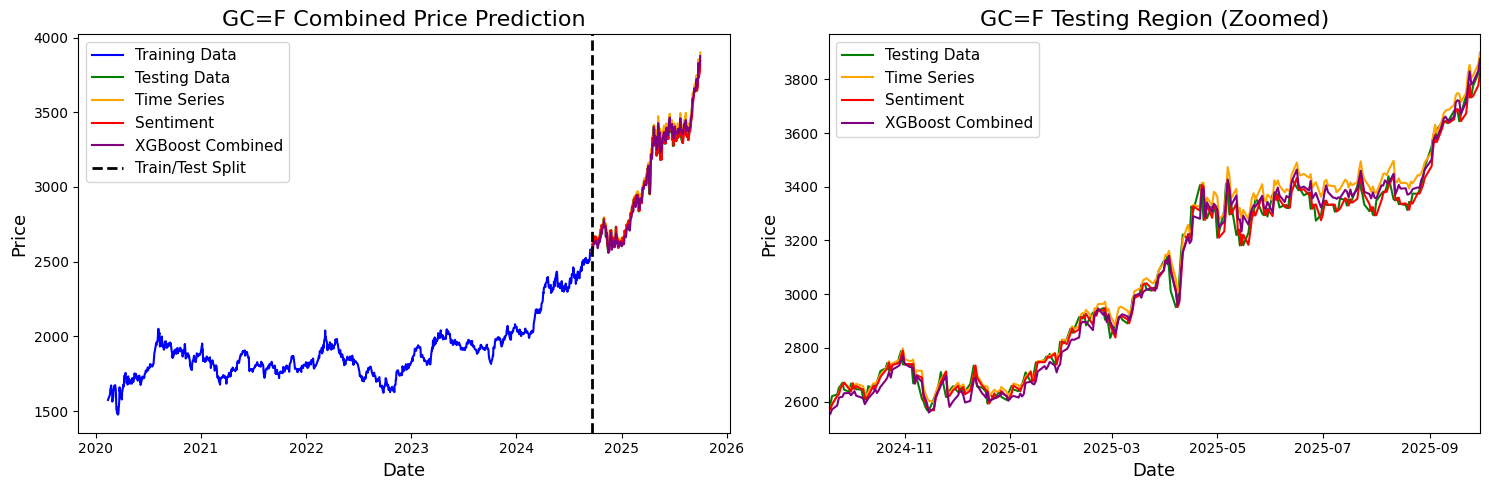

In [53]:
# Combined visualization
def plot_combined_results(train_data, test_data, ts_pred, sa_pred, xgb_pred, company_name):
    train_close = get_close_series(train_data)
    test_close = get_close_series(test_data)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Full view
    axes[0].plot(train_close.index, train_close.values, label="Training Data", color="blue")
    axes[0].plot(test_close.index, test_close.values, label="Testing Data", color="green")
    axes[0].plot(ts_pred.index, ts_pred.values, label="Time Series", color="orange")
    axes[0].plot(sa_pred.index, sa_pred.values, label="Sentiment", color="red")
    axes[0].plot(xgb_pred.index, xgb_pred.values, label="XGBoost Combined", color="purple")
    axes[0].axvline(x=test_close.index[0], color="black", linestyle="--", linewidth=2, label="Train/Test Split")
    axes[0].set_title(f"{company_name} Combined Price Prediction", fontsize=16)
    axes[0].set_xlabel("Date", fontsize=13)
    axes[0].set_ylabel("Price", fontsize=13)
    axes[0].legend(fontsize=11)

    # Zoomed test view
    axes[1].plot(test_close.index, test_close.values, label="Testing Data", color="green")
    axes[1].plot(ts_pred.index, ts_pred.values, label="Time Series", color="orange")
    axes[1].plot(sa_pred.index, sa_pred.values, label="Sentiment", color="red")
    axes[1].plot(xgb_pred.index, xgb_pred.values, label="XGBoost Combined", color="purple")
    axes[1].set_xlim(test_close.index.min(), test_close.index.max())
    axes[1].set_title(f"{company_name} Testing Region (Zoomed)", fontsize=16)
    axes[1].set_xlabel("Date", fontsize=13)
    axes[1].set_ylabel("Price", fontsize=13)
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.show()


plot_combined_results(train_data, test_data, ts_test_aligned, sa_test_aligned, xgb_combined_series, ticker)


In [54]:
# Final evaluation
actual_prices = actual_test_aligned.values
ts_metrics = evaluate_model(actual_prices, ts_test_aligned.values)
sa_metrics = evaluate_model(actual_prices, sa_test_aligned.values)
xgb_metrics = evaluate_model(actual_prices, xgb_combined_series.values)

results_df = pd.DataFrame.from_dict({
    "Time Series (TS)": ts_metrics,
    "Sentiment/News (SA)": sa_metrics,
    "XGBoost Combined": xgb_metrics
}, orient="index")

results_df.style.format({
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "R2": "{:.4f}",
    "Directional Acc": "{:.2%}",
    "Return MSE": "{:.6f}"
})


,RMSE,MAE,R2,Directional Acc,Return MSE
Time Series (TS),53.9728,41.2481,0.9755,48.85%,0.000228
Sentiment/News (SA),35.5994,26.6880,0.9893,47.69%,0.000264
XGBoost Combined,42.7909,33.8580,0.9846,51.54%,0.000222
